# Ion 参数学习

只训练 Ion；每个例子一个 CV、一个参数、一条合成目标轨迹。前两个例子拟合带 spike 的电压，其余拟合浓度。

| 参数类型 | 例子 | 更新关系 |
|---|---|---|
| 独立物理参数 | SodiumFixed.E | 直接参与电流 |
| 派生电位的上游参数 | SodiumInitNernst.temp | reset 时更新 Nernst 电位 |
| 独立初值 | CalciumDetailed.Ci_initializer | reset 时 Ci(0) = theta，随后 Ci 自行演化 |
| 浓度动力学 | CalciumDetailed.tau | 改变浓度清除速度 |
| 反应速率 | ToyCaBindingKinetic_SU2015_DCN.kf | 改变结合物形成速度 |
| 派生默认初值 | caiBase、缓冲物总量 | reset 时重新推导，显式初值覆盖优先 |
| 其他签名参数 | 开关、整数、配置等 | 不保证可微；零梯度或自然报错由实际计算决定 |

签名是候选入口，不是可辨识性保证。species/reactions/conserves 字典定义模型结构，未被删除；本例不提供嵌套字典的训练路径。


In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

from time import perf_counter
import braincell
import brainstate
import braintools
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from braincell.filter import AllRegion, RootLocation

DT = 0.025 * u.ms
STEPS = 800
EPOCHS = 100
LR = 0.03
print(f"JAX {jax.__version__}; backend={jax.default_backend()}")


JAX 0.8.0; backend=cpu


## 一个 CV 与统一训练函数

theta 是无量纲缩放参数，物理参数保留单位。每轮 loss 内先 reset，再运行模拟；优化器更新 theta，不更新模拟结束时的状态作为下一轮初值。

浓度曲线包含 t=0。CalciumDetailed 使用不等于 C_rest 的起始浓度，不接钙电流，直接展示清除过程。Toy 模型只演示一条可逆结合反应，不代表经过校准的生物模型。


In [2]:
def build_cell(model, field, value, voltage):
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type="soma",
    )
    cell = braincell.Cell(
        braincell.Morphology.from_root(soma, name="soma"),
        cv_policy=braincell.CVPerBranch(), pop_size=(1,),
        V_init=-65.0 * u.mV, solver="staggered",
    )
    params = {"Ci_initializer": 0.001 * u.mM} if model == "CalciumDetailed" else {}
    params[field] = value
    cell.paint(
        AllRegion(),
        braincell.mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * u.uF / u.cm**2,
            axial_resistivity=100.0 * u.ohm * u.cm,
        ),
        braincell.mech.Ion(model, name="pool", **params),
    )
    if voltage:
        cell.paint(
            AllRegion(),
            braincell.mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
            braincell.mech.Channel("IL", name="leak"),
            braincell.mech.Channel("Na_HH1952", name="na", ion_name="pool"),
            braincell.mech.Channel("K_HH1952", name="k"),
        )
        cell.place(
            RootLocation(0.5),
            braincell.mech.CurrentClamp(
                delay=5.0 * u.ms, durations=10.0 * u.ms, amplitudes=0.05 * u.nA,
            ),
        )
    return cell


def simulate(cell, observable):
    with brainstate.environ.context(dt=DT):
        cell.reset_state()

        def read():
            if observable == "V":
                return cell.V.value.to_decimal(u.mV).reshape(())
            return getattr(cell.get_ion("pool"), observable).value.to_decimal(u.uM).reshape(())

        initial = read()

        def step(i):
            with brainstate.environ.context(t=i * DT):
                cell.update()
                return read()

        trace = brainstate.transform.for_loop(step, jnp.arange(STEPS))
        return jnp.concatenate((initial[None], trace))


def spike_count(trace):
    v = np.asarray(trace)
    return int(np.count_nonzero((v[:-1] < 0) & (v[1:] >= 0)))


def fit_one(model, field, initial_value, target_value, observable):
    started = perf_counter()
    voltage = observable == "V"
    target_cell = build_cell(model, field, target_value, voltage)
    target_cell.init_state()
    target = brainstate.transform.jit(lambda: simulate(target_cell, observable))()
    cell = build_cell(model, field, initial_value, voltage)
    cell.ions["pool"].trainable(**{field: braincell.trainable.scale(name="theta")})
    cell.init_state()
    states = cell.trainables.parameters().states()
    assert cell.n_cv == 1 and len(states) == 1
    predict = brainstate.transform.jit(lambda: simulate(cell, observable))
    initial = np.asarray(predict())

    def loss():
        return jnp.mean((simulate(cell, observable) - target) ** 2)

    gradient = brainstate.transform.grad(loss, grad_states=states, return_value=True)
    optimizer = braintools.optim.Adam(lr=LR)
    optimizer.register_trainable_weights(states)

    @brainstate.transform.jit
    def optimize():
        def step(_):
            gradients, value = gradient()
            optimizer.update(gradients)
            return value
        return brainstate.transform.for_loop(step, jnp.arange(EPOCHS))

    history = np.asarray(optimize())
    fitted = np.asarray(predict())
    initial_mse = float(np.mean((initial - np.asarray(target)) ** 2))
    final_mse = float(np.mean((fitted - np.asarray(target)) ** 2))
    fitted_value = cell.ions["pool"].get(field)[0]
    elapsed = perf_counter() - started
    assert np.isfinite(history).all() and np.isfinite(fitted).all()
    assert final_mse <= 0.1 * initial_mse, (field, initial_mse, final_mse)
    if voltage:
        assert spike_count(target) >= 1 and spike_count(fitted) >= 1

    times = np.arange(STEPS + 1) * float(DT / u.ms)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].plot(times, target, color="black", label="Target")
    axes[0].plot(times, initial, color="#9a5835", alpha=0.7, label="Initial")
    axes[0].plot(times, fitted, "--", color="#138677", label="Fitted")
    axes[0].set(xlabel="Time (ms)", ylabel="Voltage (mV)" if voltage else "Concentration (uM)",
                title=f"{field}: {observable}")
    axes[0].legend()
    axes[1].semilogy(np.arange(EPOCHS), history)
    axes[1].set(xlabel="Adam update", ylabel="MSE")
    fig.tight_layout()
    plt.show()
    unit = u.get_unit(target_value)
    result = {
        "parameter": f"{model}.{field}", "initial": float(initial_value / unit),
        "target": float(target_value / unit), "fitted": float(fitted_value / unit),
        "initial_mse": initial_mse, "final_mse": final_mse, "seconds": elapsed,
    }
    print(result)
    return result

results = []


## 1. 固定反转电位

E 独立于 Ci/Co。改变 E 影响钠电流，不通过 Nernst 公式。


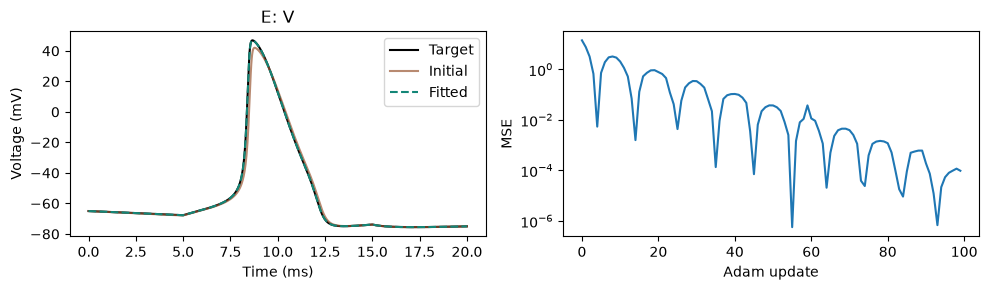

{'parameter': 'SodiumFixed.E', 'initial': 45.0, 'target': 50.0, 'fitted': 49.97644805908203, 'initial_mse': 14.18368148803711, 'final_mse': 8.104076550807804e-05, 'seconds': 10.30864984728396}


In [3]:
results.append(fit_one("SodiumFixed", "E", 45 * u.mV, 50 * u.mV, "V"))

## 2. Nernst 温度

这里只学习 Ion 的 temp；Channel 的温度固定，不共享同一个训练参数。


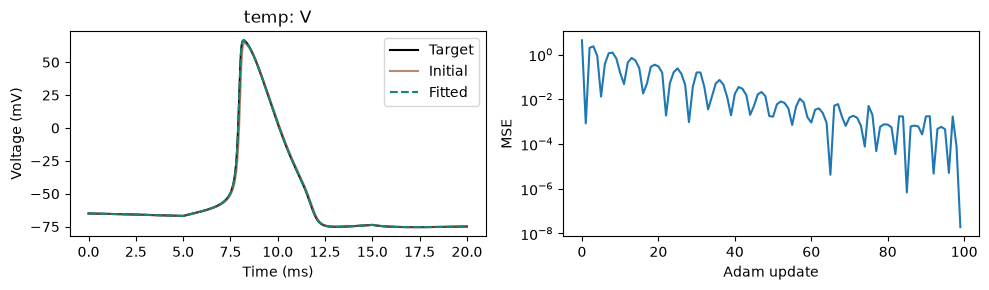

{'parameter': 'SodiumInitNernst.temp', 'initial': 300.0, 'target': 309.15, 'fitted': 309.10382080078125, 'initial_mse': 4.345213413238525, 'final_mse': 0.0003917326685041189, 'seconds': 7.129257441498339}


In [4]:
results.append(fit_one("SodiumInitNernst", "temp", 300 * u.kelvin, 309.15 * u.kelvin, "V"))

## 3. 初始浓度

学习 Ci(0)，不是把整个轨迹的 Ci(t) 固定为 theta。C_rest 和 tau 均固定。


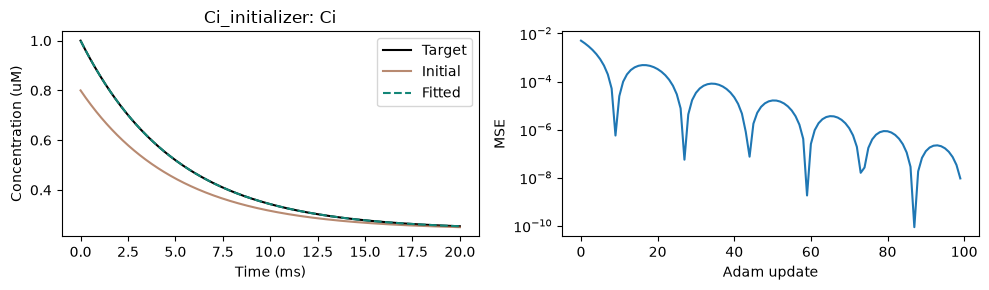

{'parameter': 'CalciumDetailed.Ci_initializer', 'initial': 0.0008, 'target': 0.001, 'fitted': 0.0009999672183766961, 'initial_mse': 0.00501708360388875, 'final_mse': 1.323315623746879e-10, 'seconds': 1.8875789353623986}


In [5]:
results.append(fit_one("CalciumDetailed", "Ci_initializer", 0.0008 * u.mM, 0.001 * u.mM, "Ci"))

## 4. 浓度清除时间常数

初始浓度固定，只改变浓度趋近 C_rest 的速度。


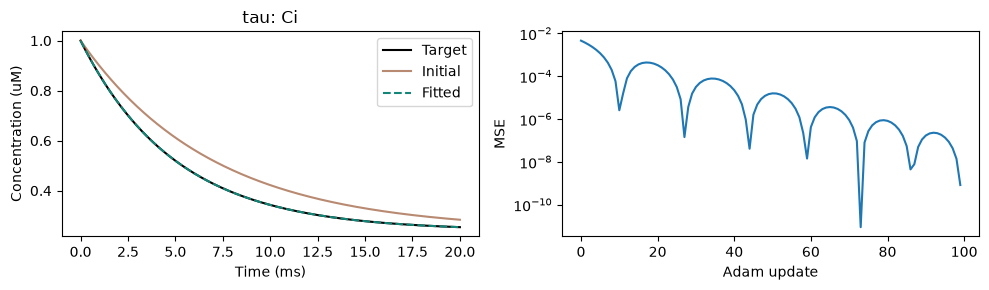

{'parameter': 'CalciumDetailed.tau', 'initial': 7.0, 'target': 5.0, 'fitted': 4.998579978942871, 'initial_mse': 0.0046277157962322235, 'final_mse': 2.8507436411473464e-09, 'seconds': 1.6922332486137748}


In [6]:
results.append(fit_one("CalciumDetailed", "tau", 7 * u.ms, 5 * u.ms, "Ci"))

## 5. 结合速率

固定初始浓度、解离速率和缓冲物总量，拟合结合物 BC 的轨迹。


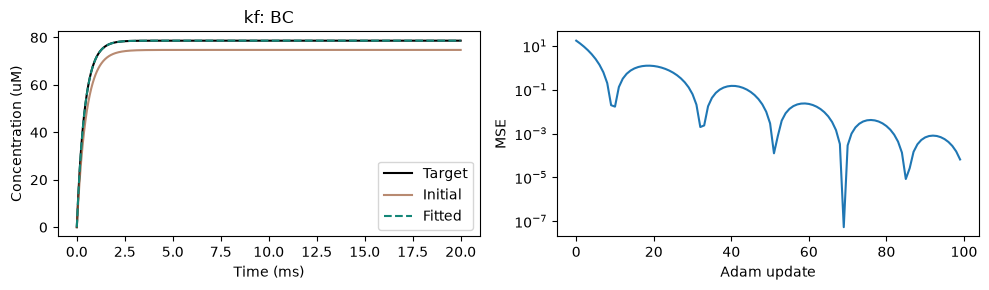

{'parameter': 'ToyCaBindingKinetic_SU2015_DCN.kf', 'initial': 1.6, 'target': 2.0, 'fitted': 2.000439167022705, 'initial_mse': 17.27889633178711, 'final_mse': 1.5111039829207584e-05, 'seconds': 2.7358450004830956}


In [7]:
results.append(fit_one("ToyCaBindingKinetic_SU2015_DCN", "kf",
                       1.6 / (u.mM * u.ms), 2.0 / (u.mM * u.ms), "BC"))

## 梯度与依赖检查

零梯度不自动等于错误：SodiumFixed 的 E 与 Ci 独立，因此以 E 为损失时，Ci 的梯度为零。类型/单位错误与训练框架中的断图错误不同，不能用后者证明一个参数不可学习。


In [8]:
checks = []
probe = build_cell("SodiumFixed", "Ci", 10 * u.mM, False)
probe.ions["pool"].trainable(Ci=braincell.trainable.scale(name="theta"))
probe.init_state()

def independent_reversal():
    probe.reset_state()
    return probe.get_ion("pool").E.to_decimal(u.mV).sum()

g = brainstate.transform.grad(independent_reversal, grad_states=probe.trainables.parameters().states())()
assert float(g["theta"]) == 0
checks.append(("SodiumFixed.Ci -> fixed E", "zero gradient", str(float(g["theta"]))))

for field, value in (("E", 1 * u.ms), ("name", "pool")):
    invalid = build_cell("SodiumFixed", "E", 50 * u.mV, False)
    try:
        invalid.ions["pool"].trainable(**{
            field: braincell.trainable.parameter(value, group_by="all"),
        })
    except (TypeError, ValueError) as exc:
        checks.append((field, "natural error", type(exc).__name__))
    else:
        raise AssertionError(f"{field} should fail")

derived = braincell.ion.CdpHVA_SU2015_DCN(size=1)
explicit = braincell.ion.CdpHVA_SU2015_DCN(size=1, Ci_initializer=0.0002 * u.mM)
derived.init_state(-65 * u.mV)
explicit.init_state(-65 * u.mV)
before = derived.Ci.value
derived.caiBase = 2 * derived.caiBase
explicit.caiBase = 2 * explicit.caiBase
derived.reset_state(-65 * u.mV)
explicit.reset_state(-65 * u.mV)
assert u.math.allclose(derived.Ci.value, 2 * before)
assert u.math.allclose(explicit.Ci.value, 0.0002 * u.mM)
checks.append(("default Ci <- caiBase", "updated", "2x"))
checks.append(("explicit Ci initializer", "independent", "unchanged"))
display(Markdown("| Check | Expected | Observed |\n|---|---|---|\n" +
                 "\n".join(f"| {a} | {b} | {c} |" for a, b, c in checks)))


| Check | Expected | Observed |
|---|---|---|
| SodiumFixed.Ci -> fixed E | zero gradient | 0.0 |
| E | natural error | ValueError |
| name | natural error | ValueError |
| default Ci <- caiBase | updated | 2x |
| explicit Ci initializer | independent | unchanged |

## 实测结果

MSE 单位：电压为 mV²，浓度为 uM²。参数恢复误差单独报告，不能把低轨迹误差当作一般性的参数可辨识性证明。耗时包括编译。


In [9]:
display(Markdown(
    "| Parameter | Initial | Target | Fitted | Relative parameter error | Initial MSE | Final MSE | Seconds |\n"
    "|---|---:|---:|---:|---:|---:|---:|---:|\n" +
    "\n".join(
        f"| {r['parameter']} | {r['initial']:.6g} | {r['target']:.6g} | {r['fitted']:.6g} | "
        f"{abs(r['fitted'] / r['target'] - 1):.3g} | {r['initial_mse']:.6g} | "
        f"{r['final_mse']:.6g} | {r['seconds']:.2f} |" for r in results
    )
))
print(f"Total fit time: {sum(r['seconds'] for r in results):.2f} s")


| Parameter | Initial | Target | Fitted | Relative parameter error | Initial MSE | Final MSE | Seconds |
|---|---:|---:|---:|---:|---:|---:|---:|
| SodiumFixed.E | 45 | 50 | 49.9764 | 0.000471 | 14.1837 | 8.10408e-05 | 10.31 |
| SodiumInitNernst.temp | 300 | 309.15 | 309.104 | 0.000149 | 4.34521 | 0.000391733 | 7.13 |
| CalciumDetailed.Ci_initializer | 0.0008 | 0.001 | 0.000999967 | 3.28e-05 | 0.00501708 | 1.32332e-10 | 1.89 |
| CalciumDetailed.tau | 7 | 5 | 4.99858 | 0.000284 | 0.00462772 | 2.85074e-09 | 1.69 |
| ToyCaBindingKinetic_SU2015_DCN.kf | 1.6 | 2 | 2.00044 | 0.00022 | 17.2789 | 1.5111e-05 | 2.74 |

Total fit time: 23.75 s
